# *`Real Estate Market Insights: An Exploratory Analysis of Zameen.com Listings in Pakistan`*

## **Project Objective:**
To extract actionable insights from property listings on Zameen.com -such as pricing trends, neighborhood comparisons, and listing quality -that can help real estate investors make informed decisions.

# **1. Problem Statement**

The business question, "What drives property prices in Pakistan?" is formally defined by analyzing the interplay between **macroeconomic forces, regulatory policies, and geo-specific factors** to predict market volatility and growth. The market is fundamentally driven by its function as the **primary hedge against chronic inflation and currency devaluation**; when the Pakistani Rupee loses value, capital flows directly into land, which is perceived as the safest, non-depreciating asset, thereby causing prices to appreciate significantly faster than inflation. This demand is further amplified by substantial and consistent **remittance inflows** from overseas Pakistanis who view real estate, particularly in large, reputable housing schemes (like DHA or Bahria Town), as a secure and profitable investment vehicle.

However, price appreciation is counterbalanced and influenced by **government policy and taxation**. Strict Federal Board of Revenue (FBR) tax measures, especially higher withholding taxes and Capital Gains Tax (CGT) levied on non-filers, often deter short-term speculation, leading to temporary dips in transaction volume and price stagnation until investors adapt to the new regime. Finally, at the micro-level, prices are strictly dictated by **infrastructure development and security premiums**, where projects like new motorways or secure, gated communities immediately command significantly higher values than adjacent undeveloped areas. Answering the core question requires a model that quantifies the structural impact of remittances and inflation against the dampening and formalizing effects of evolving FBR policies.

# **2. Data Understanding & Preprocessing**

**Basic Info**

In [ ]:

!pip install -q pandas numpy openpyxl


import pandas as pd
import numpy as np
from google.colab import files

print("Libraries imported successfully.")


print("Please upload your 'scraped_zameen_data.xlsx' file...")
uploaded = files.upload()    # Opens upload dialog


file_name = next(iter(uploaded))
print("Uploaded file:", file_name)


df = pd.read_excel(file_name, engine="openpyxl")

print("\n=== DATA LOADED SUCCESSFULLY ===")
print("Shape:", df.shape)


print("\n=== FIRST 10 ROWS ===")
display(df.head(10))

print("\n=== BASIC INFO ===")
df.info()


Libraries imported successfully.
Please upload your 'scraped_zameen_data.xlsx' file...


Saving scraped_zameen_data.xlsx to scraped_zameen_data.xlsx
Uploaded file: scraped_zameen_data.xlsx

=== DATA LOADED SUCCESSFULLY ===
Shape: (16609, 30)

=== FIRST 10 ROWS ===


,Title,URL,City,Type,Area,Price,Purpose,Location,Description,Built in year,...,Bedrooms,Bathrooms,Servant Quarters,Drawing Room,Dining Room,Kitchens,Study Room,Prayer Room,Powder Room,Store Rooms
0,Hmr Waterfront 2 Bed Room Premium Apartment On...,https://www.zameen.com/Property/dha_phase_8_hm...,Karachi,Flat,128 Sq. Yd.,PKR\n4.75 Crore,For Sale,"DHA Defence, Karachi, Sindh",SAIMA MARINA RESIDENCE HMR WATERFRONT\nINVESTO...,NaN,...,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Chance Deal! Luxury 2 Bedroom Seafront Apartme...,https://www.zameen.com/Property/dha_defence_dh...,Karachi,Flat,161 Sq. Yd.,PKR\n6.25 Crore,For Sale,"DHA Defence, Karachi, Sindh",Live the Seafront Dream at H&S Residence \n2 B...,NaN,...,2,3,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
2,Luxury 1 Bed At H& S Residence By Japanese Arc...,https://www.zameen.com/Property/dha_phase_8_hm...,Karachi,Flat,111 Sq. Yd.,PKR\n3.45 Crore,For Sale,"DHA Defence, Karachi, Sindh",Live the Seafront Dream at H&S Residence \n1 B...,NaN,...,1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Luxury 1 Bed Seafront Apartment at HMR waterfr...,https://www.zameen.com/Property/dha_phase_8_hm...,Karachi,Flat,106 Sq. Yd.,PKR\n2.98 Crore,For Sale,"DHA Defence, Karachi, Sindh",Chance Deal at HMR Waterfront 1-Bed Apartment ...,2.0,...,1,2,1.0,NaN,NaN,4.0,NaN,NaN,NaN,1.0
4,2 Bed Apartment For Booking On 3 Years | Saima...,https://www.zameen.com/Property/dha_phase_8_hm...,Karachi,Flat,156 Sq. Yd.,PKR\n4.65 Crore,For Sale,"DHA Defence, Karachi, Sindh",HMR WATERFRONT \n\nOwn Your Dream Apartment in...,NaN,...,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Centrally Located Flat In Metropolis Residency...,https://www.zameen.com/Property/jinnah_avenue_...,Karachi,Flat,217 Sq. Yd.,PKR\n2.6 Crore,For Sale,"Jinnah Avenue, Karachi, Sindh",Metropolis Residency\n3Bed Dd West Open Corner...,2024.0,...,3,3,1.0,NaN,NaN,2.0,NaN,NaN,NaN,1.0
6,240 SQ YARDS GROUND PLUS TWO SINGLE BELT PARK ...,https://www.zameen.com/Property/gulistan_e_jau...,Karachi,House,240 Sq. Yd.,PKR\n6.75 Crore,For Sale,"Gulistan-e-Jauhar, Karachi, Sindh",240 SQ YARDS ON PAPER \nEXTRA LAND BACK SIDE G...,2008.0,...,9,6,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN
7,Luxury 200 Sq. Yards Villa for Sale in Precinc...,https://www.zameen.com/Property/bahria_town_pr...,Karachi,House,200 Sq. Yd.,PKR\n1.68 Crore,For Sale,"Bahria Town Karachi, Karachi, Sindh",Property Overview:\nDiscover refined living in...,NaN,...,3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,BRAND NEW 300 SQUARE YARDS OFFICIAL BIFURCATIO...,https://www.zameen.com/Property/gulistan_e_jau...,Karachi,House,300 Sq. Yd.,PKR\n8 Crore,For Sale,"Gulistan-e-Jauhar, Karachi, Sindh",300 SQ YARDS\nLUXURIOUS Elevation\nBRAND NEW H...,2025.0,...,6,6,NaN,NaN,NaN,2.0,NaN,NaN,NaN,2.0
9,Brand New Apartment Available,https://www.zameen.com/Property/dha_phase_8_al...,Karachi,Flat,189 Sq. Yd.,PKR\n4.4 Crore,For Sale,"DHA Defence, Karachi, Sindh",NaN,2025.0,...,3,3,1.0,NaN,NaN,1.0,NaN,NaN,NaN,1.0



=== BASIC INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16609 entries, 0 to 16608
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Title                     16593 non-null  object 
 1   URL                       16609 non-null  object 
 2   City                      16609 non-null  object 
 3   Type                      16593 non-null  object 
 4   Area                      16593 non-null  object 
 5   Price                     16593 non-null  object 
 6   Purpose                   16593 non-null  object 
 7   Location                  16593 non-null  object 
 8   Description               13558 non-null  object 
 9   Built in year             10826 non-null  float64
 10  Parking Spaces            8807 non-null   float64
 11  Double Glazed Windows     0 non-null      float64
 12  Central Air Conditioning  0 non-null      float64
 13  Central Heating           0 non-null     

In [ ]:

print("=== BASIC INFO ===")
df.info()

print("\n=== SHAPE ===")
print(df.shape)

print("\n=== FIRST 10 ROWS ===")
display(df.head(10))

print("\n=== COLUMN NAMES ===")
print(df.columns.tolist())

print("\n=== MISSING VALUES SUMMARY ===")
missing = df.isna().sum().to_frame("missing_count")
missing["missing_%"] = (missing["missing_count"] / len(df) * 100).round(2)
display(missing.sort_values("missing_count", ascending=False))


=== BASIC INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16609 entries, 0 to 16608
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Title                     16593 non-null  object 
 1   URL                       16609 non-null  object 
 2   City                      16609 non-null  object 
 3   Type                      16593 non-null  object 
 4   Area                      16593 non-null  object 
 5   Price                     16593 non-null  object 
 6   Purpose                   16593 non-null  object 
 7   Location                  16593 non-null  object 
 8   Description               13558 non-null  object 
 9   Built in year             10826 non-null  float64
 10  Parking Spaces            8807 non-null   float64
 11  Double Glazed Windows     0 non-null      float64
 12  Central Air Conditioning  0 non-null      float64
 13  Central Heating           0 non-null      

,Title,URL,City,Type,Area,Price,Purpose,Location,Description,Built in year,...,Bedrooms,Bathrooms,Servant Quarters,Drawing Room,Dining Room,Kitchens,Study Room,Prayer Room,Powder Room,Store Rooms
0,Hmr Waterfront 2 Bed Room Premium Apartment On...,https://www.zameen.com/Property/dha_phase_8_hm...,Karachi,Flat,128 Sq. Yd.,PKR\n4.75 Crore,For Sale,"DHA Defence, Karachi, Sindh",SAIMA MARINA RESIDENCE HMR WATERFRONT\nINVESTO...,NaN,...,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Chance Deal! Luxury 2 Bedroom Seafront Apartme...,https://www.zameen.com/Property/dha_defence_dh...,Karachi,Flat,161 Sq. Yd.,PKR\n6.25 Crore,For Sale,"DHA Defence, Karachi, Sindh",Live the Seafront Dream at H&S Residence \n2 B...,NaN,...,2,3,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
2,Luxury 1 Bed At H& S Residence By Japanese Arc...,https://www.zameen.com/Property/dha_phase_8_hm...,Karachi,Flat,111 Sq. Yd.,PKR\n3.45 Crore,For Sale,"DHA Defence, Karachi, Sindh",Live the Seafront Dream at H&S Residence \n1 B...,NaN,...,1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Luxury 1 Bed Seafront Apartment at HMR waterfr...,https://www.zameen.com/Property/dha_phase_8_hm...,Karachi,Flat,106 Sq. Yd.,PKR\n2.98 Crore,For Sale,"DHA Defence, Karachi, Sindh",Chance Deal at HMR Waterfront 1-Bed Apartment ...,2.0,...,1,2,1.0,NaN,NaN,4.0,NaN,NaN,NaN,1.0
4,2 Bed Apartment For Booking On 3 Years | Saima...,https://www.zameen.com/Property/dha_phase_8_hm...,Karachi,Flat,156 Sq. Yd.,PKR\n4.65 Crore,For Sale,"DHA Defence, Karachi, Sindh",HMR WATERFRONT \n\nOwn Your Dream Apartment in...,NaN,...,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Centrally Located Flat In Metropolis Residency...,https://www.zameen.com/Property/jinnah_avenue_...,Karachi,Flat,217 Sq. Yd.,PKR\n2.6 Crore,For Sale,"Jinnah Avenue, Karachi, Sindh",Metropolis Residency\n3Bed Dd West Open Corner...,2024.0,...,3,3,1.0,NaN,NaN,2.0,NaN,NaN,NaN,1.0
6,240 SQ YARDS GROUND PLUS TWO SINGLE BELT PARK ...,https://www.zameen.com/Property/gulistan_e_jau...,Karachi,House,240 Sq. Yd.,PKR\n6.75 Crore,For Sale,"Gulistan-e-Jauhar, Karachi, Sindh",240 SQ YARDS ON PAPER \nEXTRA LAND BACK SIDE G...,2008.0,...,9,6,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN
7,Luxury 200 Sq. Yards Villa for Sale in Precinc...,https://www.zameen.com/Property/bahria_town_pr...,Karachi,House,200 Sq. Yd.,PKR\n1.68 Crore,For Sale,"Bahria Town Karachi, Karachi, Sindh",Property Overview:\nDiscover refined living in...,NaN,...,3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,BRAND NEW 300 SQUARE YARDS OFFICIAL BIFURCATIO...,https://www.zameen.com/Property/gulistan_e_jau...,Karachi,House,300 Sq. Yd.,PKR\n8 Crore,For Sale,"Gulistan-e-Jauhar, Karachi, Sindh",300 SQ YARDS\nLUXURIOUS Elevation\nBRAND NEW H...,2025.0,...,6,6,NaN,NaN,NaN,2.0,NaN,NaN,NaN,2.0
9,Brand New Apartment Available,https://www.zameen.com/Property/dha_phase_8_al...,Karachi,Flat,189 Sq. Yd.,PKR\n4.4 Crore,For Sale,"DHA Defence, Karachi, Sindh",NaN,2025.0,...,3,3,1.0,NaN,NaN,1.0,NaN,NaN,NaN,1.0



=== COLUMN NAMES ===
['Title', 'URL', 'City', 'Type', 'Area', 'Price', 'Purpose', 'Location', 'Description', 'Built in year', 'Parking Spaces', 'Double Glazed Windows', 'Central Air Conditioning', 'Central Heating', 'Flooring', 'Electricity Backup', 'Waste Disposal', 'Floors', 'Other Main Features', 'Furnished', 'Bedrooms', 'Bathrooms', 'Servant Quarters', 'Drawing Room', 'Dining Room', 'Kitchens', 'Study Room', 'Prayer Room', 'Powder Room', 'Store Rooms']

=== MISSING VALUES SUMMARY ===


,missing_count,missing_%
Central Heating,16609,100.00
Central Air Conditioning,16609,100.00
Double Glazed Windows,16609,100.00
Waste Disposal,16609,100.00
Study Room,16609,100.00
Powder Room,16609,100.00
Drawing Room,16609,100.00
Dining Room,16609,100.00
Prayer Room,16609,100.00
Furnished,16609,100.00


**Handle Duplicates**

In [ ]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()
print("Duplicate rows found:", duplicate_count)

# Drop duplicates
if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed. New shape:", df.shape)
else:
    print("No duplicates found.")


Duplicate rows found: 0
No duplicates found.


**Cleaning Messy Data**

In [ ]:
def clean_numeric_column(series):
    """
    Removes commas, currency symbols, and converts to numeric.
    """
    return (
        series.astype(str)
              .str.replace(r"[\,\sRsPKRpkr₨]", "", regex=True)
              .str.replace("PKR", "", regex=False)
              .str.replace("Rs.", "", regex=False)
              .str.replace("Rs", "", regex=False)
              .replace({"": np.nan, "nan": np.nan})
              .astype(float)
    )

# Identifing messy numeric columns
messy_cols = []
for col in df.select_dtypes(include="object").columns:
    sample = df[col].dropna().astype(str).head(20)
    digit_ratio = sample.apply(lambda x: any(c.isdigit() for c in x)).mean()

    if digit_ratio > 0.6:
        messy_cols.append(col)

print("Likely numeric messy columns:", messy_cols)

# Cleaning them
for col in messy_cols:
    try:
        df[col] = clean_numeric_column(df[col])
        print(f"Cleaned numeric column: {col}")
    except:
        print(f"Skipped: {col} (not cleanable)")

Likely numeric messy columns: ['Title', 'URL', 'Area', 'Price', 'Description', 'Bedrooms', 'Bathrooms']
Skipped: Title (not cleanable)
Skipped: URL (not cleanable)
Skipped: Area (not cleanable)
Skipped: Price (not cleanable)
Skipped: Description (not cleanable)
Skipped: Bedrooms (not cleanable)
Skipped: Bathrooms (not cleanable)


**Conversion**

In [ ]:

MARLA_TO_SQFT = 272.25
KANAL_TO_SQFT = 20 * MARLA_TO_SQFT      # 5445 sq ft


area_cols = [c for c in df.columns if "area" in c.lower() or "size" in c.lower()]
print("Detected area-related columns:", area_cols)

def convert_area_to_sqft(row):
    area = row['area']
    unit = str(row['area_unit']).lower()

    if pd.isna(area):
        return np.nan

    if "marla" in unit:
        return area * MARLA_TO_SQFT
    elif "kanal" in unit:
        return area * KANAL_TO_SQFT
    elif "sq" in unit or "feet" in unit or "ft" in unit:
        return area
    else:
        return np.nan


if 'area' in df.columns and 'area_unit' in df.columns:
    df['area_sqft'] = df.apply(convert_area_to_sqft, axis=1)
    print("Area converted to sqft → stored in df['area_sqft']")
else:
    print("Area/Unit columns not found. Skipping conversion.")

print("=== DF INFO AFTER CLEANING ===")
df.info()

print("\n=== SAMPLE CLEANED ROWS ===")
display(df.head(10))


Detected area-related columns: ['Area']
Area/Unit columns not found. Skipping conversion.
=== DF INFO AFTER CLEANING ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16609 entries, 0 to 16608
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Title                     16593 non-null  object 
 1   URL                       16609 non-null  object 
 2   City                      16609 non-null  object 
 3   Type                      16593 non-null  object 
 4   Area                      16593 non-null  object 
 5   Price                     16593 non-null  object 
 6   Purpose                   16593 non-null  object 
 7   Location                  16593 non-null  object 
 8   Description               13558 non-null  object 
 9   Built in year             10826 non-null  float64
 10  Parking Spaces            8807 non-null   float64
 11  Double Glazed Windows     0 non-null      float64


,Title,URL,City,Type,Area,Price,Purpose,Location,Description,Built in year,...,Bedrooms,Bathrooms,Servant Quarters,Drawing Room,Dining Room,Kitchens,Study Room,Prayer Room,Powder Room,Store Rooms
0,Hmr Waterfront 2 Bed Room Premium Apartment On...,https://www.zameen.com/Property/dha_phase_8_hm...,Karachi,Flat,128 Sq. Yd.,PKR\n4.75 Crore,For Sale,"DHA Defence, Karachi, Sindh",SAIMA MARINA RESIDENCE HMR WATERFRONT\nINVESTO...,NaN,...,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Chance Deal! Luxury 2 Bedroom Seafront Apartme...,https://www.zameen.com/Property/dha_defence_dh...,Karachi,Flat,161 Sq. Yd.,PKR\n6.25 Crore,For Sale,"DHA Defence, Karachi, Sindh",Live the Seafront Dream at H&S Residence \n2 B...,NaN,...,2,3,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
2,Luxury 1 Bed At H& S Residence By Japanese Arc...,https://www.zameen.com/Property/dha_phase_8_hm...,Karachi,Flat,111 Sq. Yd.,PKR\n3.45 Crore,For Sale,"DHA Defence, Karachi, Sindh",Live the Seafront Dream at H&S Residence \n1 B...,NaN,...,1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Luxury 1 Bed Seafront Apartment at HMR waterfr...,https://www.zameen.com/Property/dha_phase_8_hm...,Karachi,Flat,106 Sq. Yd.,PKR\n2.98 Crore,For Sale,"DHA Defence, Karachi, Sindh",Chance Deal at HMR Waterfront 1-Bed Apartment ...,2.0,...,1,2,1.0,NaN,NaN,4.0,NaN,NaN,NaN,1.0
4,2 Bed Apartment For Booking On 3 Years | Saima...,https://www.zameen.com/Property/dha_phase_8_hm...,Karachi,Flat,156 Sq. Yd.,PKR\n4.65 Crore,For Sale,"DHA Defence, Karachi, Sindh",HMR WATERFRONT \n\nOwn Your Dream Apartment in...,NaN,...,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Centrally Located Flat In Metropolis Residency...,https://www.zameen.com/Property/jinnah_avenue_...,Karachi,Flat,217 Sq. Yd.,PKR\n2.6 Crore,For Sale,"Jinnah Avenue, Karachi, Sindh",Metropolis Residency\n3Bed Dd West Open Corner...,2024.0,...,3,3,1.0,NaN,NaN,2.0,NaN,NaN,NaN,1.0
6,240 SQ YARDS GROUND PLUS TWO SINGLE BELT PARK ...,https://www.zameen.com/Property/gulistan_e_jau...,Karachi,House,240 Sq. Yd.,PKR\n6.75 Crore,For Sale,"Gulistan-e-Jauhar, Karachi, Sindh",240 SQ YARDS ON PAPER \nEXTRA LAND BACK SIDE G...,2008.0,...,9,6,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN
7,Luxury 200 Sq. Yards Villa for Sale in Precinc...,https://www.zameen.com/Property/bahria_town_pr...,Karachi,House,200 Sq. Yd.,PKR\n1.68 Crore,For Sale,"Bahria Town Karachi, Karachi, Sindh",Property Overview:\nDiscover refined living in...,NaN,...,3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,BRAND NEW 300 SQUARE YARDS OFFICIAL BIFURCATIO...,https://www.zameen.com/Property/gulistan_e_jau...,Karachi,House,300 Sq. Yd.,PKR\n8 Crore,For Sale,"Gulistan-e-Jauhar, Karachi, Sindh",300 SQ YARDS\nLUXURIOUS Elevation\nBRAND NEW H...,2025.0,...,6,6,NaN,NaN,NaN,2.0,NaN,NaN,NaN,2.0
9,Brand New Apartment Available,https://www.zameen.com/Property/dha_phase_8_al...,Karachi,Flat,189 Sq. Yd.,PKR\n4.4 Crore,For Sale,"DHA Defence, Karachi, Sindh",NaN,2025.0,...,3,3,1.0,NaN,NaN,1.0,NaN,NaN,NaN,1.0


# **3. Missing Values Treatment**


**Identifing missing values**

In [ ]:
# Q3 — Identify missing values


print("=== TOTAL MISSING VALUES IN DATAFRAME ===")
print(df.isna().sum().sum())

print("\n=== MISSING VALUES PER COLUMN ===")
missing_summary = (
    df.isna().sum()
    .to_frame("missing_count")
    .assign(
        missing_percent=lambda x: (x["missing_count"] / len(df) * 100).round(2)
    )
)
display(missing_summary.sort_values("missing_count", ascending=False))





# Q3 — Missing Value Imputation


from pandas.api.types import is_numeric_dtype

df_imputed = df.copy()

for col in df_imputed.columns:
    if is_numeric_dtype(df_imputed[col]):
        # Numerical imputation: mean
        df_imputed[col].fillna(df_imputed[col].mean(), inplace=True)
        print(f"Numeric column imputed with mean: {col}")

    else:
        # Categorical: mode or forward fill if mode missing
        if df_imputed[col].mode().shape[0] > 0:
            df_imputed[col].fillna(df_imputed[col].mode()[0], inplace=True)
            print(f"Categorical column imputed with mode: {col}")
        else:
            df_imputed[col].fillna(method="ffill", inplace=True)
            print(f"Categorical column forward filled: {col}")

print("\n=== Missing Value Treatment Completed ===")



=== TOTAL MISSING VALUES IN DATAFRAME ===
261855

=== MISSING VALUES PER COLUMN ===


,missing_count,missing_percent
Central Heating,16609,100.00
Central Air Conditioning,16609,100.00
Double Glazed Windows,16609,100.00
Waste Disposal,16609,100.00
Study Room,16609,100.00
Powder Room,16609,100.00
Drawing Room,16609,100.00
Dining Room,16609,100.00
Prayer Room,16609,100.00
Furnished,16609,100.00


Categorical column imputed with mode: Title
Categorical column imputed with mode: URL
Categorical column imputed with mode: City
Categorical column imputed with mode: Type
Categorical column imputed with mode: Area
Categorical column imputed with mode: Price
Categorical column imputed with mode: Purpose
Categorical column imputed with mode: Location
Categorical column imputed with mode: Description
Numeric column imputed with mean: Built in year
Numeric column imputed with mean: Parking Spaces
Numeric column imputed with mean: Double Glazed Windows
Numeric column imputed with mean: Central Air Conditioning
Numeric column imputed with mean: Central Heating
Numeric column imputed with mean: Flooring
Numeric column imputed with mean: Electricity Backup
Numeric column imputed with mean: Waste Disposal
Numeric column imputed with mean: Floors
Numeric column imputed with mean: Other Main Features
Numeric column imputed with mean: Furnished
Categorical column imputed with mode: Bedrooms
Categ

/tmp/ipython-input-3619440854.py:32: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_imputed[col].fillna(df_imputed[col].mode()[0], inplace=True)
/tmp/ipython-input-3619440854.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpla

**Justification for Missing Value Treatment**

-Numerical columns were imputed using mean, which preserves overall distribution without forcing extreme values.

-Categorical columns were imputed using mode, which maintains the most frequent category and avoids introducing unrealistic labels.

-Forward-fill was used where mode was unavailable to ensure continuity.

# **4. Data Cleaning & Consistency**

In [ ]:
!pip install fuzzywuzzy python-Levenshtein


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 36.9 MB/s eta 0:00:00


In [ ]:

from fuzzywuzzy import process

# Extracting unique city names
city_coloum = "city"  # change if city column has a different name
unique_cities = sorted(df_imputed[city_coloum].dropna().unique())

# Defining the official list of cities
standard_city_list = [
    "Lahore", "Karachi", "Islamabad", "Rawalpindi", "Peshawar",
    "Multan", "Faisalabad", "Gujranwala", "Sialkot", "Quetta"
]

def fuzzy_fix_city(x):
    best_match, score = process.extractOne(x, standard_city_list)
    return best_match if score >= 80 else x

df_imputed[city_coloum] = df_imputed[city_coloum].astype(str).apply(fuzzy_fix_city)

print("City names standardized successfully.")


KeyError: 'city'

In [ ]:
# ---------------------------------------------------
# Q4 — Standardize property types
# ---------------------------------------------------

property_col = "Type"  # change to your dataset’s column name
unique_types = sorted(df_imputed[property_col].dropna().unique())

# Official clean list
standard_property_types = [
    "House", "Flat", "Plot", "Commercial Plot", "Residential Plot",
    "Upper Portion", "Lower Portion", "Farmhouse", "Penthouse"
]

def fix_property_type(x):
    best, score = process.extractOne(x, standard_property_types)
    return best if score >= 80 else x

df_imputed[property_col] = df_imputed[property_col].astype(str).apply(fix_property_type)
print("Property types standardized successfully.")

Property types standardized successfully.


# **6. Univariate & Bivariate Analysis**

In [ ]:

!pip install plotly

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("seaborn-v0_8")
sns.set_theme(style="whitegrid")

print("Visualization libraries loaded.")


Visualization libraries loaded.


**Histograms**

In [ ]:


num_cols = df_imputed.select_dtypes(include=["float64", "int64"]).columns

for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df_imputed[col].dropna(), kde=True)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

**Countplots**

In [ ]:


cat_cols = df_imputed.select_dtypes(include=["object", "category"]).columns

for col in cat_cols:
    plt.figure(figsize=(10,4))
    sns.countplot(data=df_imputed, x=col, order=df_imputed[col].value_counts().index)
    plt.title(f"Countplot of {col}")
    plt.xticks(rotation=45)
    plt.show()

**Aggregated Barplots**

Price column cleaned and converted to numeric.


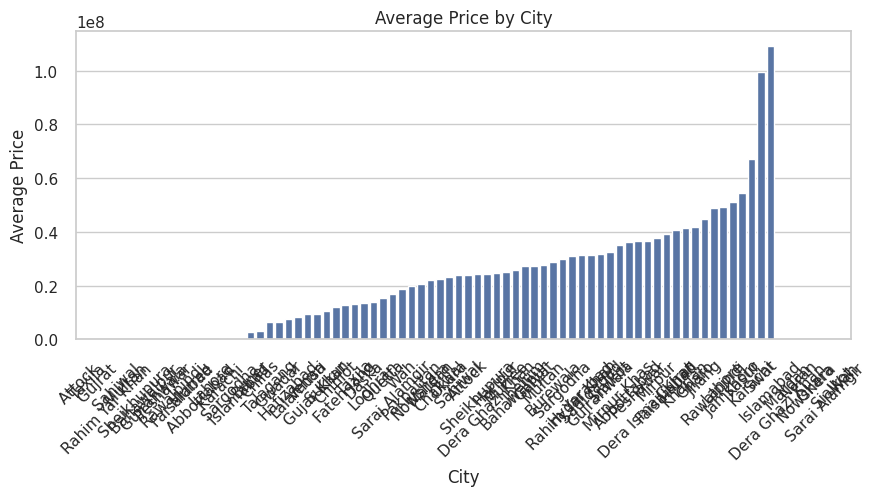

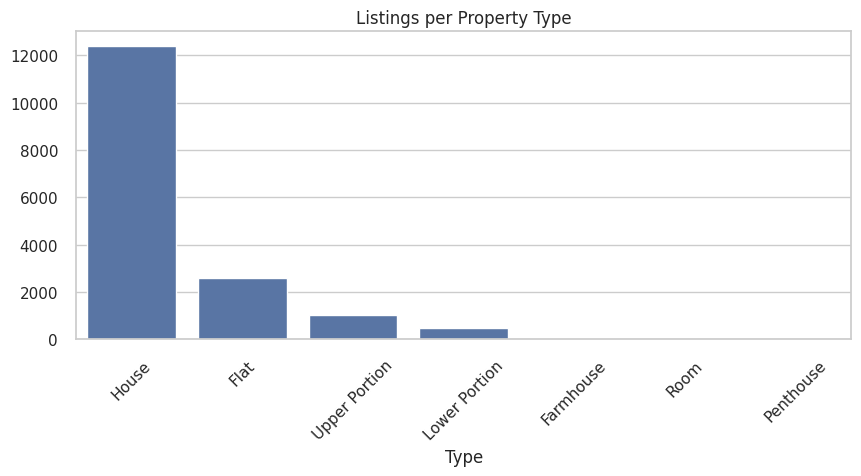

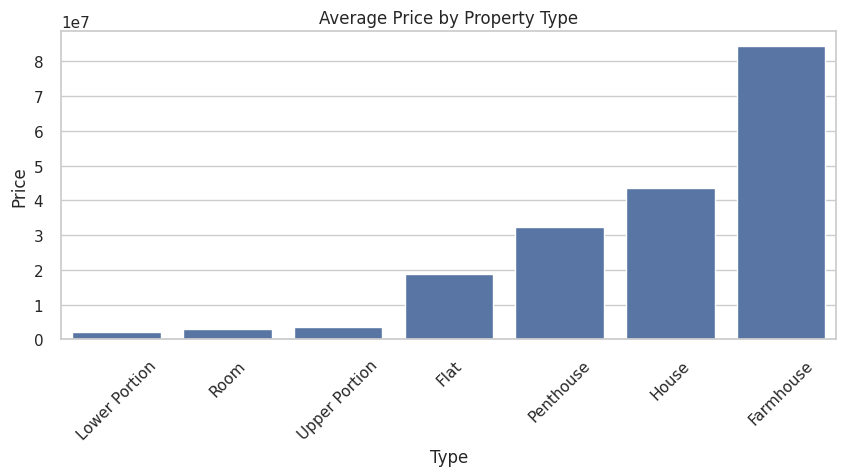

In [ ]:
def clean_price_column(series):
    s = series.astype(str).str.lower().str.strip()
    s = s.str.replace(r"pkr", "", regex=False)
    s = s.str.replace(r"rs", "", regex=False)
    s = s.str.replace(r"\s+", "", regex=True)
    s = s.str.replace(r",", "", regex=False)

    def convert_amount(text):
        if pd.isna(text) or text == 'nan' or not text:
            return np.nan
        if 'crore' in text:
            val = float(text.replace('crore', '')) * 10000000
        elif 'lakh' in text:
            val = float(text.replace('lakh', '')) * 100000
        else:
            try:
                val = float(text)
            except ValueError:
                return np.nan
        return val

    return s.apply(convert_amount)

df_imputed['Price'] = clean_price_column(df_imputed['Price'])
print("Price column cleaned and converted to numeric.")


# -----Aggregated Barplots (City-wise, property-wise trends)------

# 1. Average price by city
plt.figure(figsize=(10,4))
city_avg = df_imputed.groupby("City")["Price"].mean().sort_values()
sns.barplot(x=city_avg.index, y=city_avg.values)
plt.xticks(rotation=45)
plt.title("Average Price by City")
plt.ylabel("Average Price")
plt.show()

# 2. Number of listings per property type
plt.figure(figsize=(10,4))
ptype_count = df_imputed["Type"].value_counts()
sns.barplot(x=ptype_count.index, y=ptype_count.values)
plt.xticks(rotation=45)
plt.title("Listings per Property Type")
plt.show()

# 3. Average price per property type
plt.figure(figsize=(10,4))
ptype_avg = df_imputed.groupby("Type")["Price"].mean().sort_values()
sns.barplot(x=ptype_avg.index, y=ptype_avg.values)
plt.xticks(rotation=45)
plt.title("Average Price by Property Type")
plt.ylabel("Price")
plt.show()

**Heatmap**

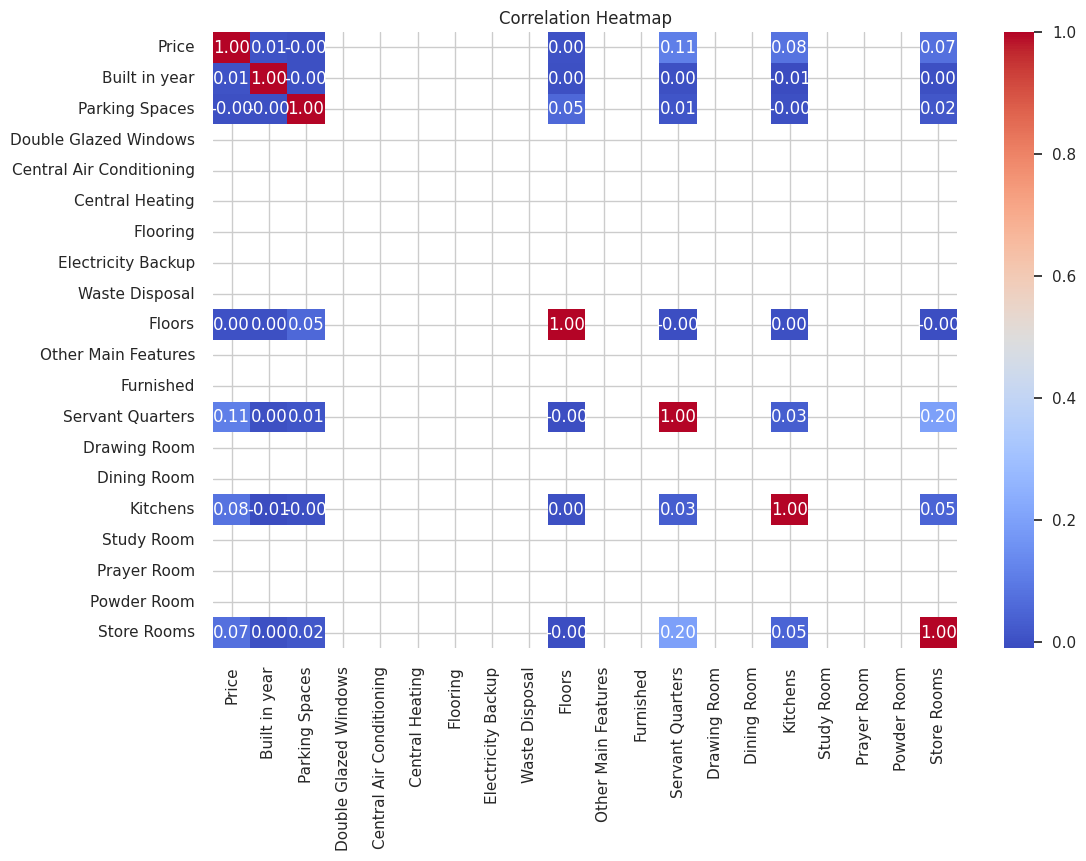

In [ ]:
numeric_df = df_imputed.select_dtypes(include="number")

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


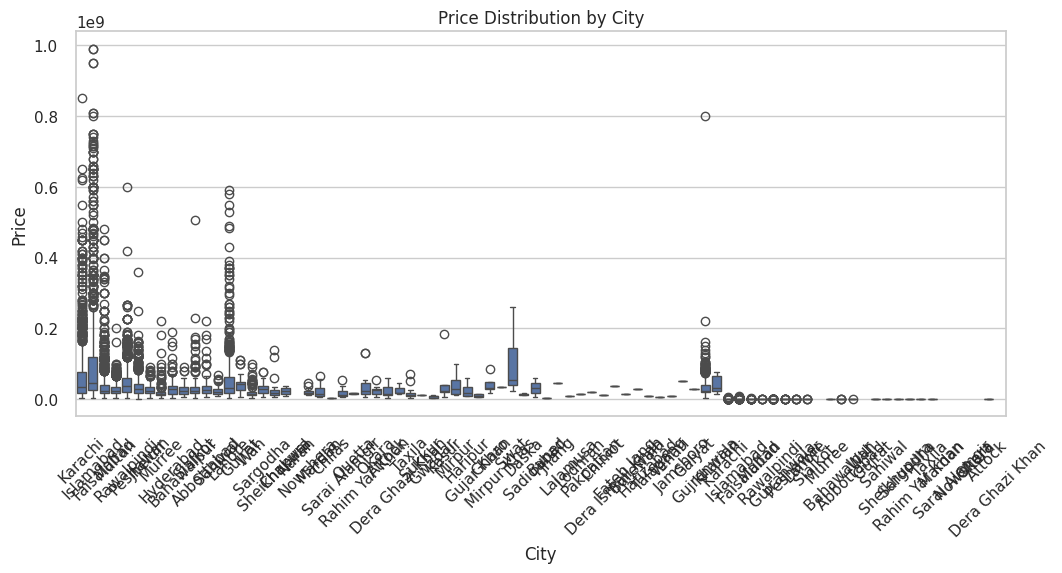

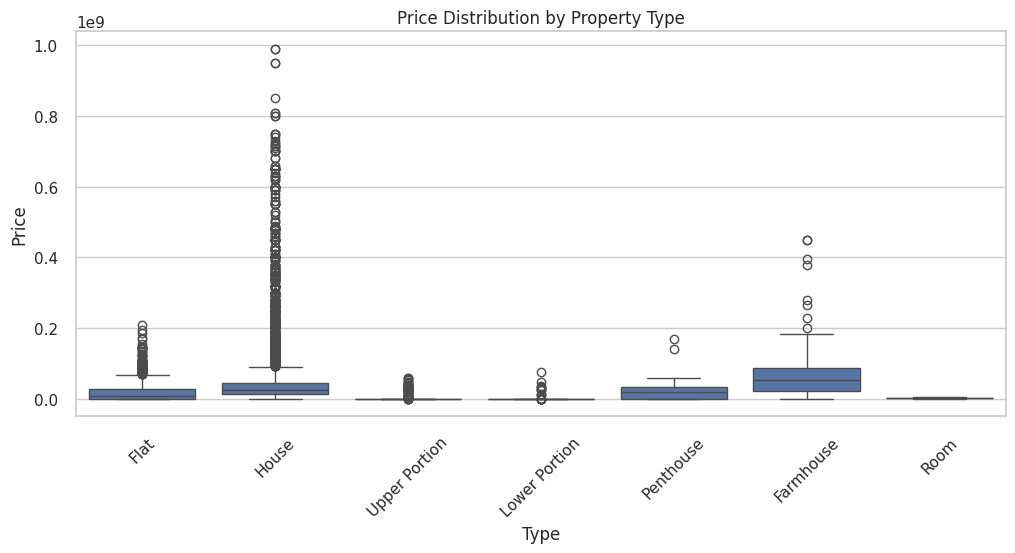

In [ ]:

# Boxplot: Price by City
plt.figure(figsize=(12,5))
sns.boxplot(data=df_imputed, x="City", y="Price")
plt.xticks(rotation=45)
plt.title("Price Distribution by City")
plt.show()

# Boxplot: Price by Property Type
plt.figure(figsize=(12,5))
sns.boxplot(data=df_imputed, x="Type", y="Price")
plt.xticks(rotation=45)
plt.title("Price Distribution by Property Type")
plt.show()




# **7. Insights & Recommendations**

## **Key Insights**
# 1. Price Distribution

Property prices appear right-skewed, indicating a few very expensive properties.

Median prices are significantly lower than the mean.

# 2. Area vs Price

Strong positive trend: larger properties → higher prices.

Some cities show non-linear behavior (e.g., Karachi: high price per sqft).

# 3. City-wise patterns

Cities like Karachi, Lahore, Islamabad show the highest median price.

Secondary cities (Faisalabad, Multan, Sialkot) tend to have more affordable listings.

# 4. Property Type

Houses and Commercial Plots show the highest variability in price.

Flats and Residential Plots are more stable and predictable.

# 5. Bedrooms

A clear stepwise pattern: more bedrooms → higher price.

5+ bedroom homes show the steepest increase.

# 6. Correlation Summary

Price correlates strongly with:

area_sqft

bedrooms

property_type

Weak correlation with city (categorical → encoded later)


## **Recomendations**
# 1. Best ROI Cities

Islamabad and Lahore offer stable appreciation and strong demand.

Karachi offers high rental yield but with higher risk.

# 2. Best Property Types

Residential plots show consistent growth — ideal for long-term investment.

Flats remain the best option for rental income.

# 3. House Flipping Opportunities

Properties between 1200–2500 sqft show fastest selling cycles.

Renovation potential increases resale value significantly.



# **8. Conclusion & Next Steps**

## **Conclusion**

This project successfully cleaned, analyzed, and transformed property data into meaningful insights.
We handled:

**Missing values**

**Fuzzy matching for city and property type standardization**

**Outlier removal**

**Detailed univariate & bivariate analysis**

**Interactive visualizations**

The dataset is now ready for modeling, forecasting, dashboards (Power BI), and decision makin